#### Исходный график сигнала:

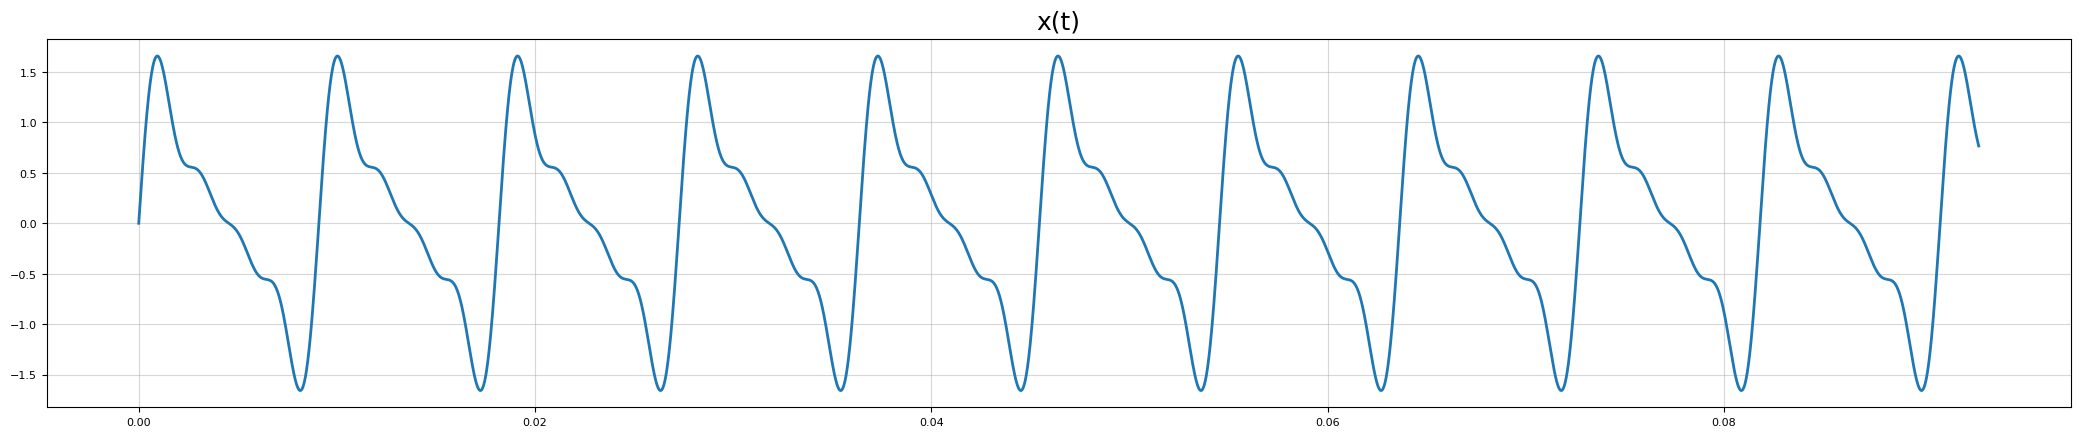

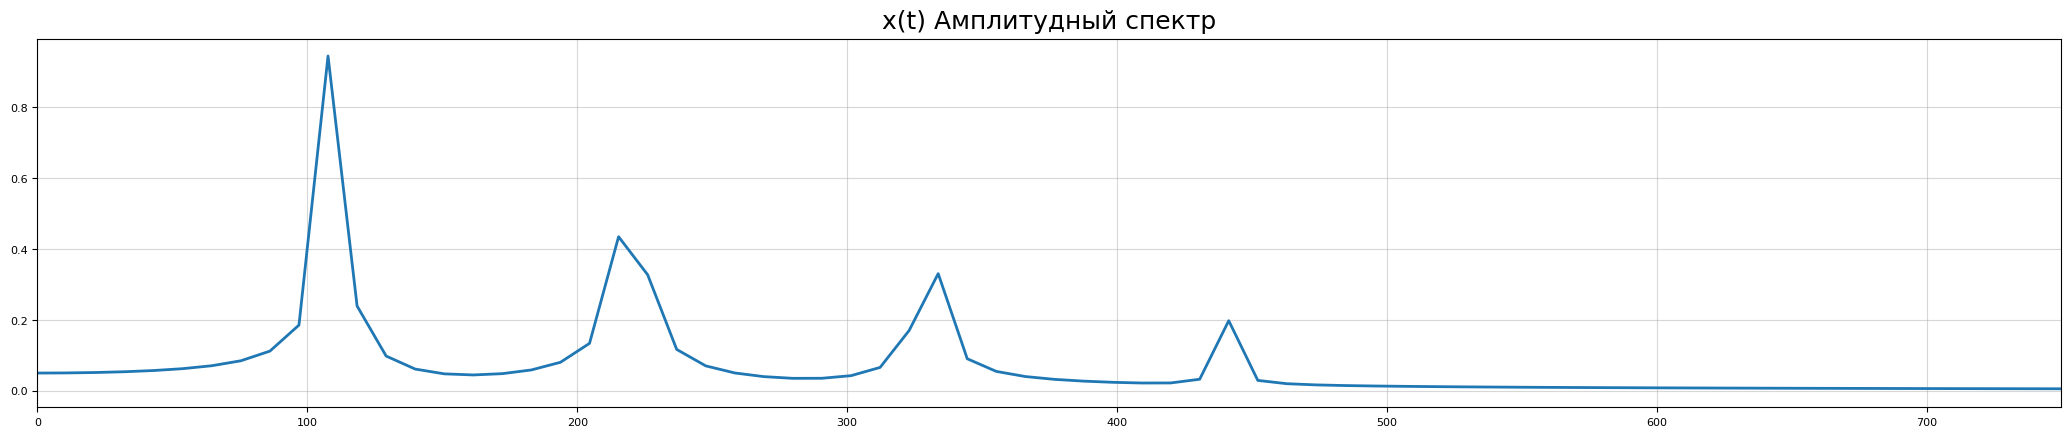

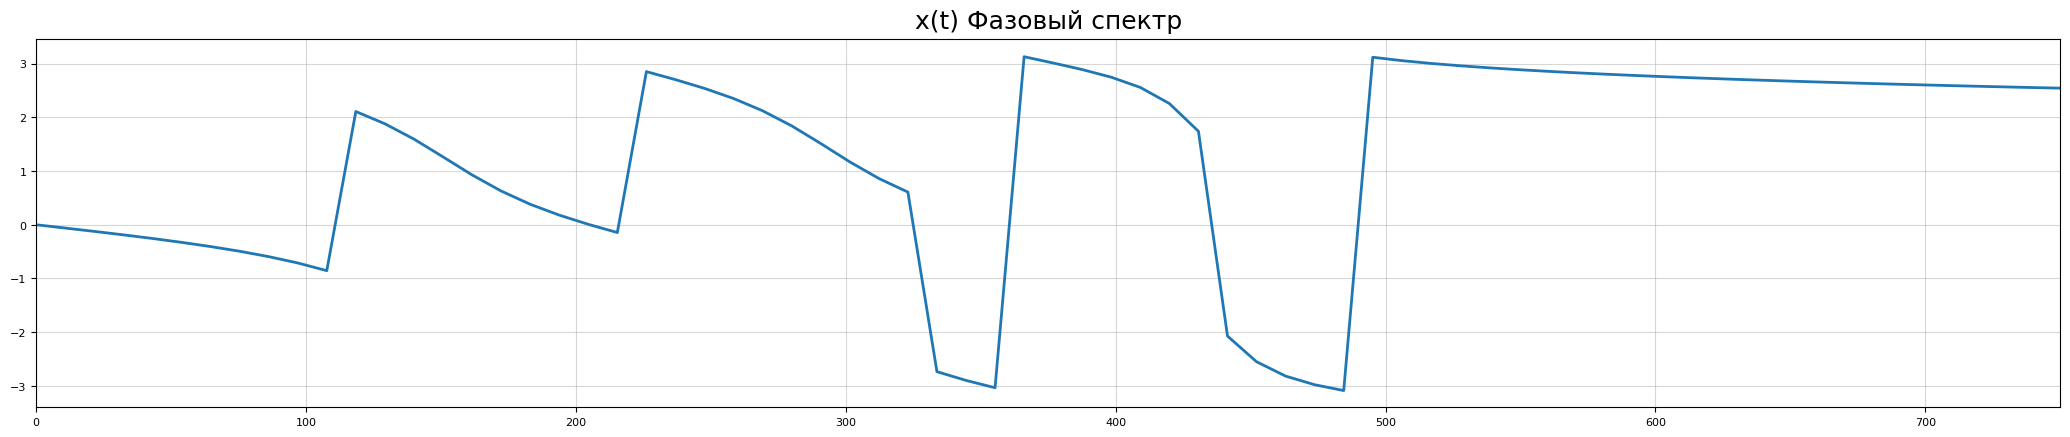

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy import signal

fs = 44100
N_plot = 4096
t_plot = np.arange(N_plot) / fs

A_x, f0_x, h_x = [1, 0.6, 0.4, 0.2], 110, [1, 2, 3, 4]

def generate_signal(A, f0, h, t):
    s = np.zeros_like(t)
    for Ai, hi in zip(A, h):
        s += Ai * np.sin(2 * np.pi * hi * f0 * t)
    return s

x = generate_signal(A_x, f0_x, h_x, t_plot)

freq = np.arange(N_plot) * fs / N_plot
X_fft = fft(x)
mag = 2 * np.abs(X_fft[:N_plot//2]) / N_plot
phase = np.angle(X_fft[:N_plot//2])

def draw_plot(x_data, y_data, title, color='tab:blue', x_lim=None):
    plt.figure(figsize=(22, 4), facecolor='white')
    plt.plot(x_data, y_data, color=color, linewidth=2)
    
    plt.title(title, fontsize=18, pad=8)
    plt.grid(True, alpha=0.5)
    plt.tick_params(axis='both', labelsize=8) 
    
    if x_lim is not None:
        plt.xlim(0, x_lim)
    
    plt.gca().locator_params(axis='both', nbins=10)
    plt.subplots_adjust(left=0.04, right=0.96, top=0.96, bottom=0.04)
    plt.show()

draw_plot(t_plot, x, "x(t)")
draw_plot(freq[:N_plot//2], mag, "x(t) Амплитудный спектр", x_lim=750)
draw_plot(freq[:N_plot//2], phase, "x(t) Фазовый спектр", x_lim=750)

#### График сигнала с добавлением шума:

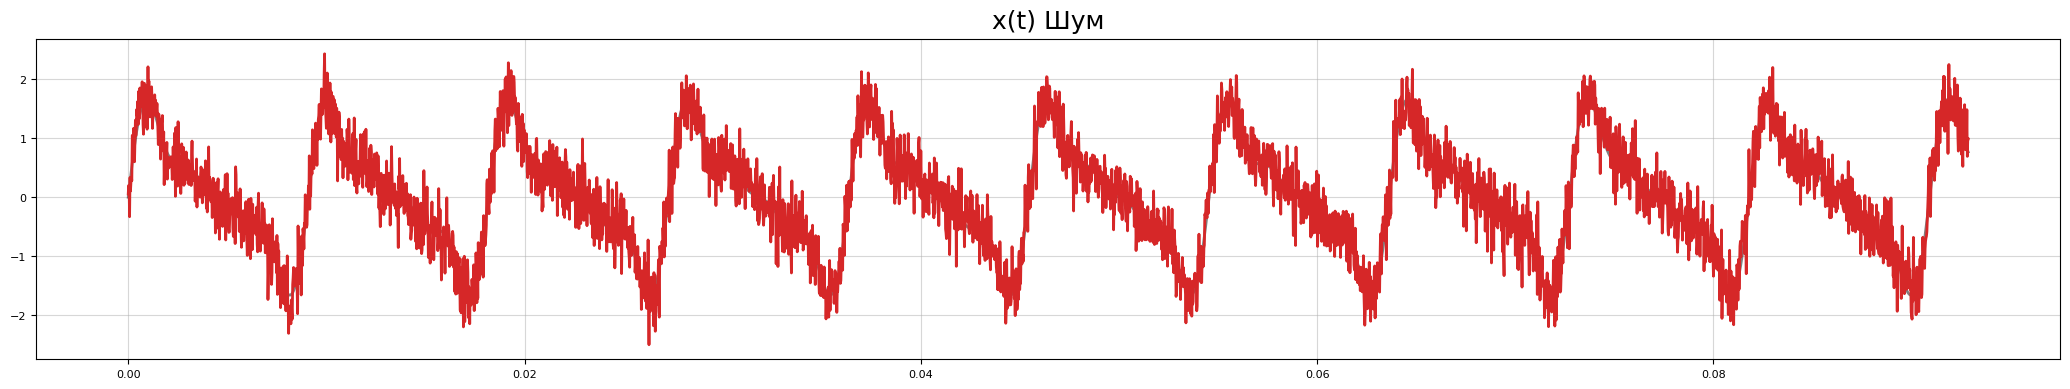

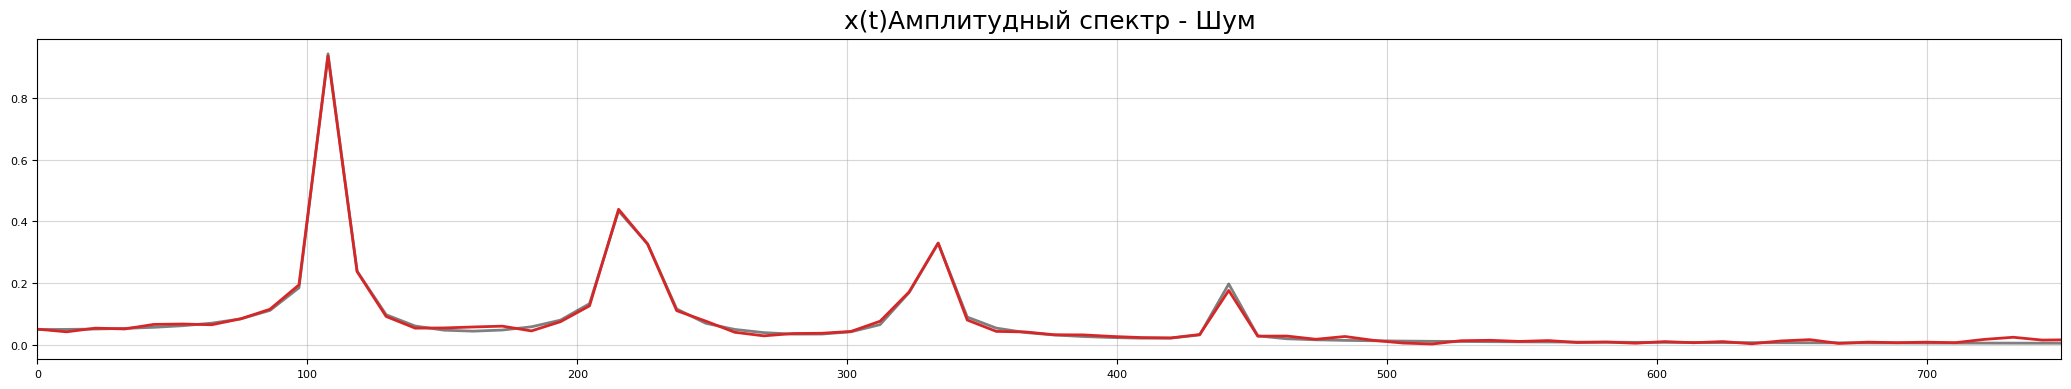

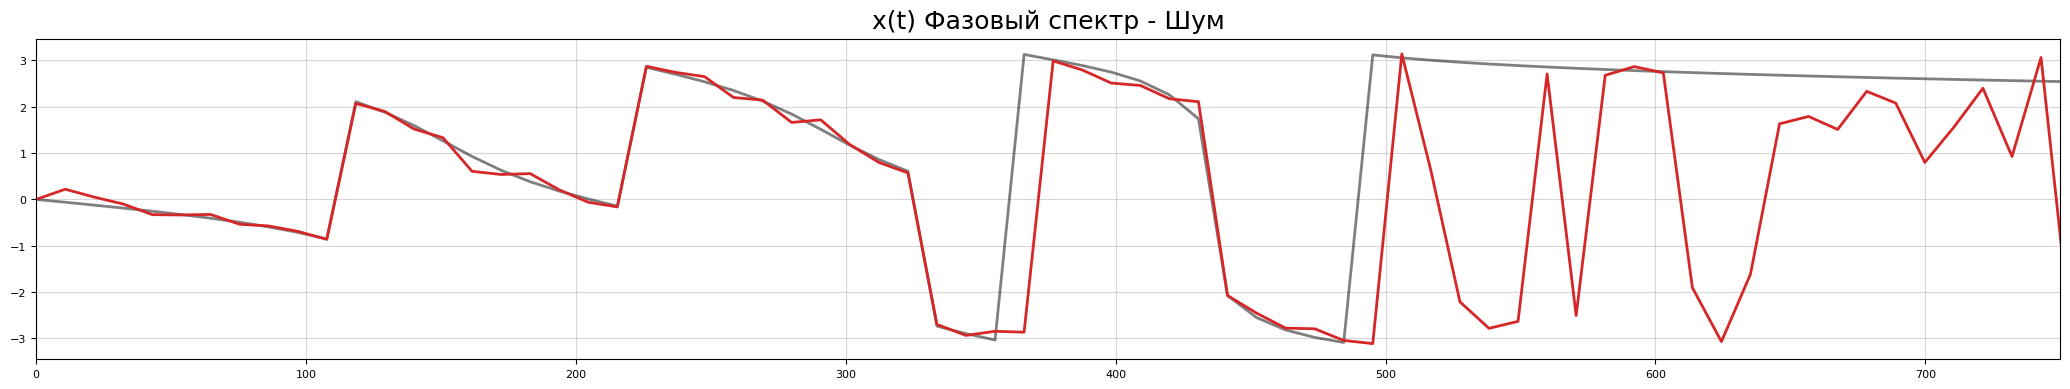

In [74]:
noise = 0.3 * np.random.normal(size=N_plot)
x_noisy = x + noise

X_fft_noisy = fft(x_noisy)
mag_noisy = 2 * np.abs(X_fft_noisy[:N_plot//2]) / N_plot
phase_noisy = np.angle(X_fft_noisy[:N_plot//2])

def draw_comparison_plot(x_vals, y_clean, y_noisy, title, x_lim=None):
    plt.figure(figsize=(22, 4), facecolor='white')
    
    plt.plot(x_vals, y_clean, color='black', linewidth=2, label='Original', alpha=0.5)
    plt.plot(x_vals, y_noisy, color='tab:red', linewidth=2, label='Noisy')
        
    plt.title(title, fontsize=18, pad=8)
    plt.grid(True, alpha=0.5)
    plt.tick_params(axis='both', labelsize=8)
    
    if x_lim is not None:
        plt.xlim(0, x_lim)
    
    plt.gca().locator_params(axis='both', nbins=10)
    plt.subplots_adjust(left=0.04, right=0.96, top=0.9, bottom=0.1)
    plt.show()

draw_comparison_plot(t_plot, x, x_noisy, "x(t) Шум")
draw_comparison_plot(freq[:N_plot//2], mag, mag_noisy, "x(t)Амплитудный спектр - Шум", x_lim=750)
draw_comparison_plot(freq[:N_plot//2], phase, phase_noisy, "x(t) Фазовый спектр - Шум", x_lim=750)

#### Однородный фильтр:

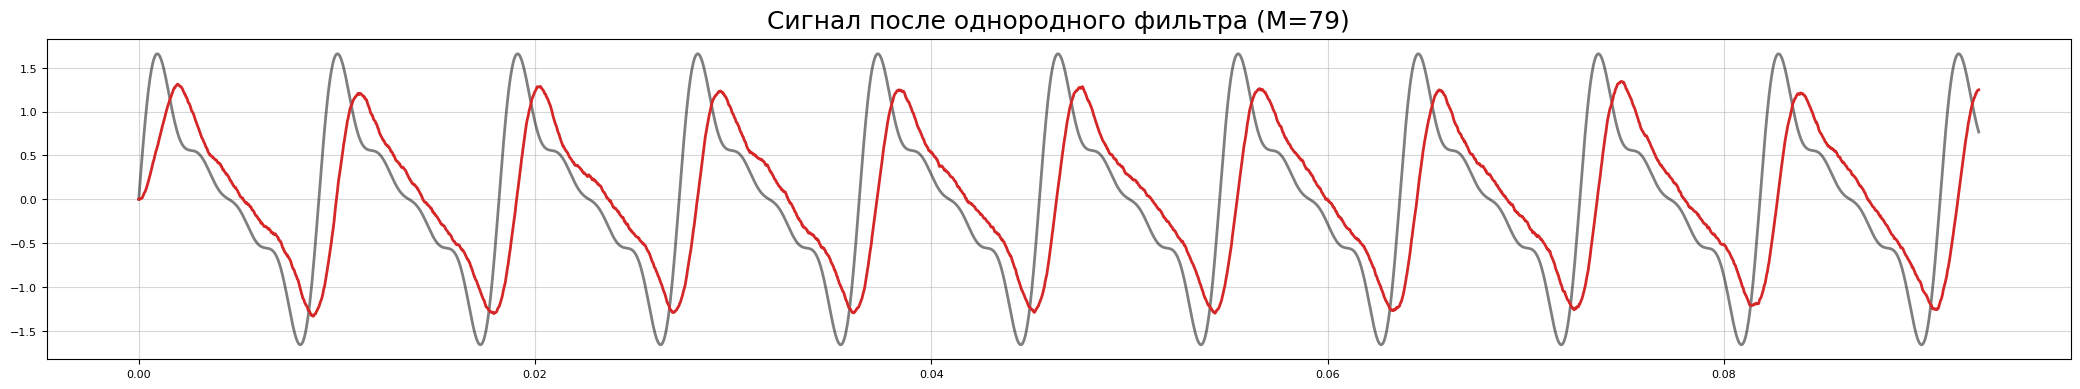

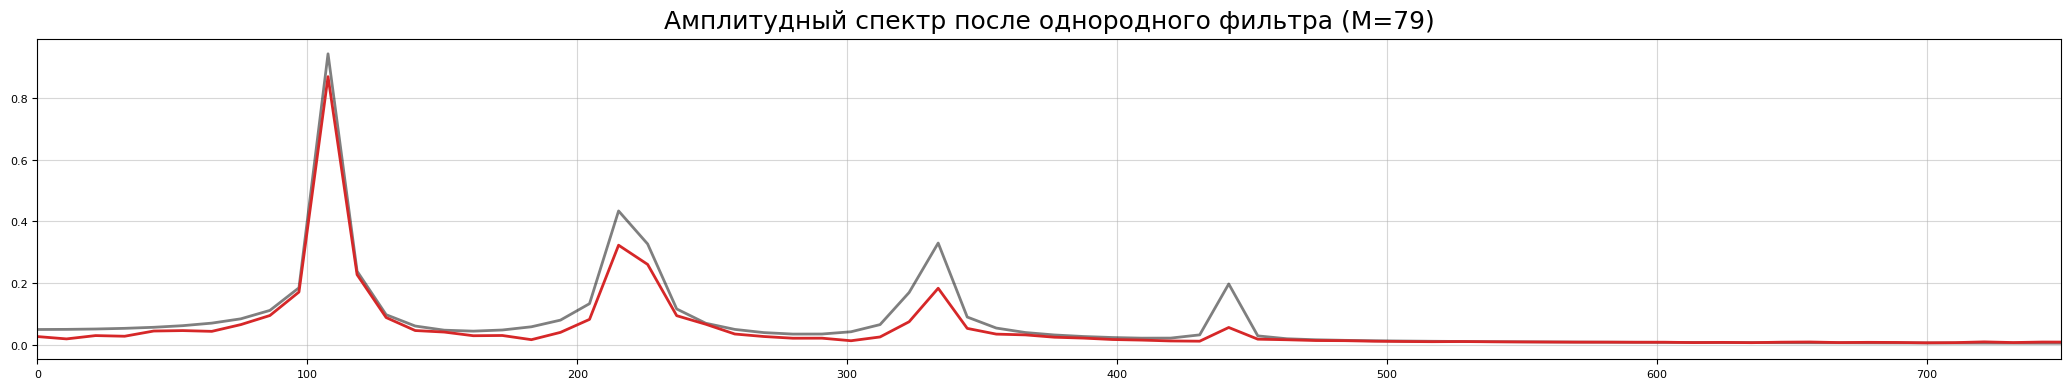

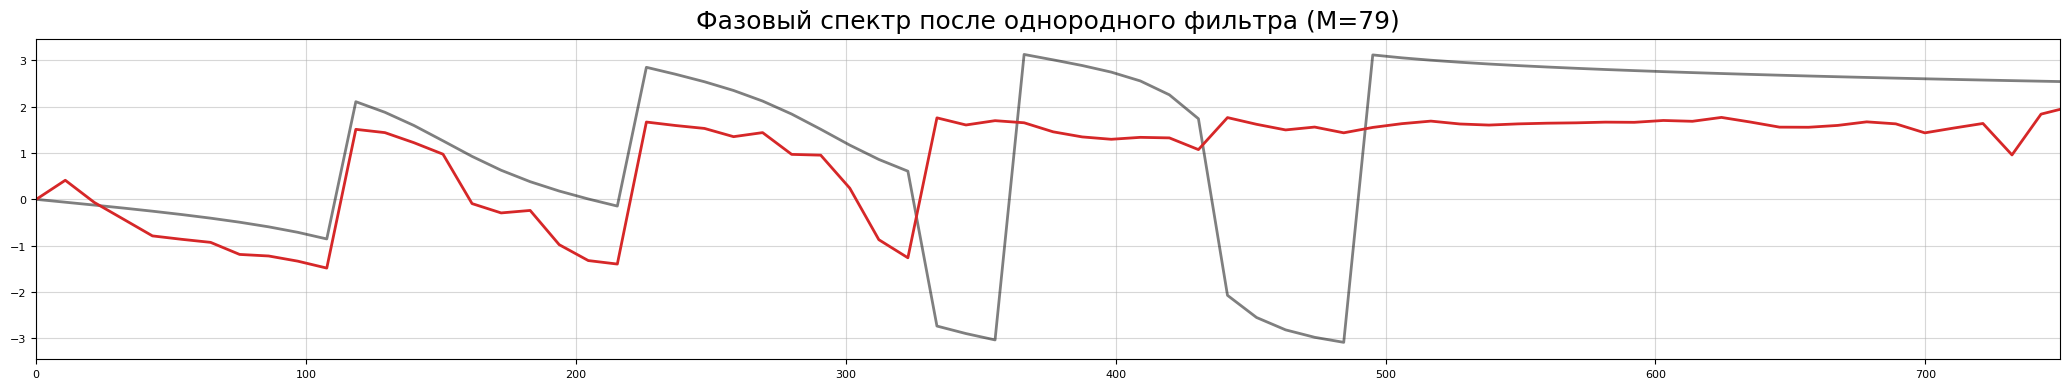

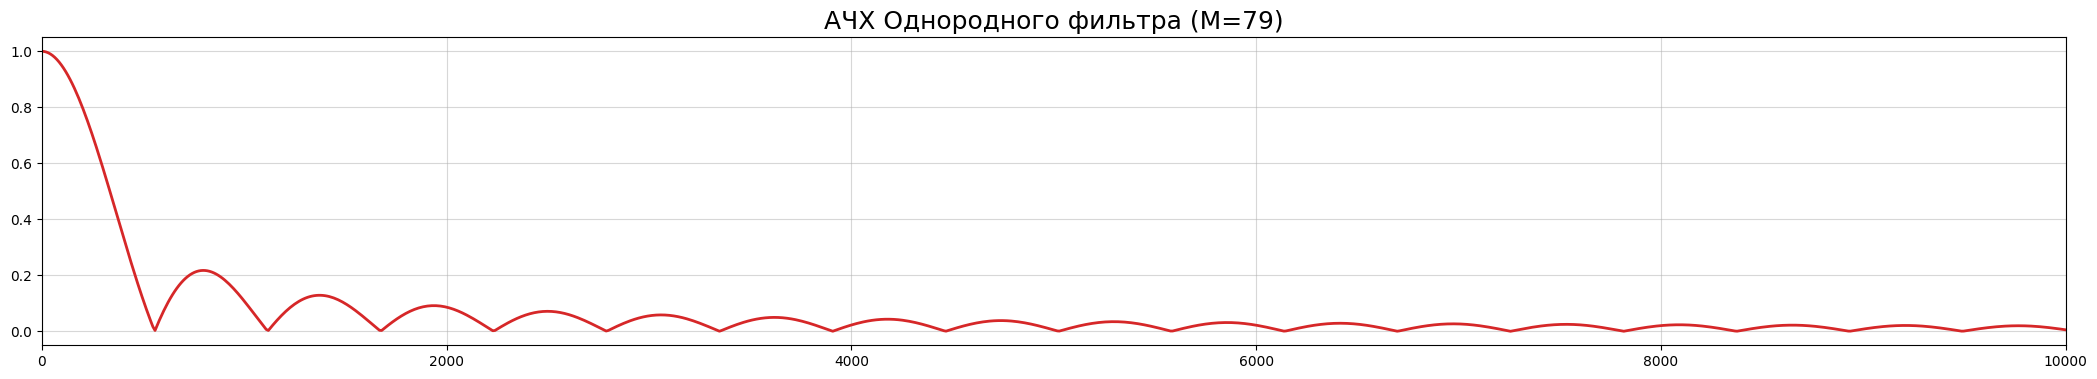

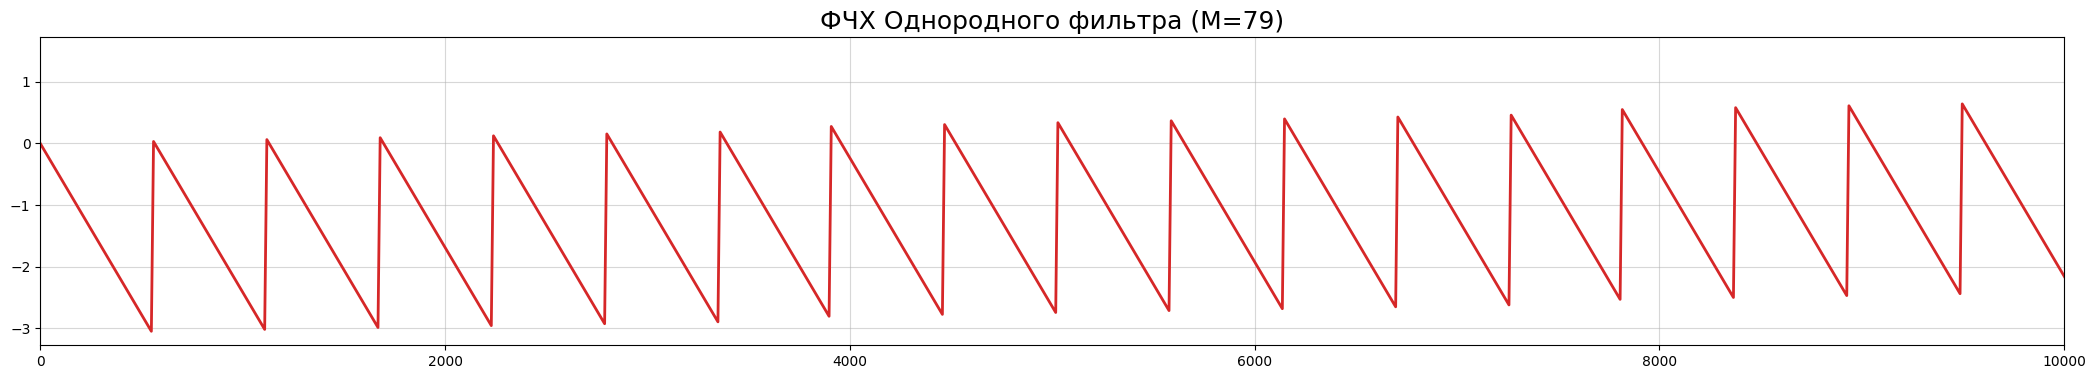

In [75]:
M = 79
x_padded = np.pad(x_noisy, (M, 0), mode='constant')
y_filtered = np.zeros_like(x_padded)

for n in range(M, len(x_padded)):
    y_filtered[n] = y_filtered[n-1] + (x_padded[n] - x_padded[n-M]) / M

y_final = y_filtered[M:] 
Y_fft = fft(y_final)
mag_filtered = 2 * np.abs(Y_fft[:N_plot//2]) / N_plot
phase_filtered = np.angle(Y_fft[:N_plot//2])

h = np.ones(M) / M
w, h_freq = signal.freqz(h, worN=N_plot//2)
response_mag = np.abs(h_freq)
response_phase = np.angle(h_freq)
freq_hz = w * fs / (2 * np.pi)

def draw_characteristics(f, m, p, title_m, title_p, x_lim=10000):
    plt.figure(figsize=(22, 4), facecolor='white')
    plt.plot(f, m, color='tab:red', linewidth=2)
    plt.title(title_m, fontsize=18)
    plt.grid(True, alpha=0.5)
    plt.xlim(0, x_lim)
    plt.subplots_adjust(left=0.04, right=0.96)
    plt.show()
    
    plt.figure(figsize=(22, 4), facecolor='white')
    plt.plot(f, p, color='tab:red', linewidth=2)
    plt.title(title_p, fontsize=18)
    plt.grid(True, alpha=0.5)
    plt.xlim(0, x_lim)
    plt.subplots_adjust(left=0.04, right=0.96)
    plt.show()

draw_comparison_plot(t_plot, x, y_final, f"Сигнал после однородного фильтра (M={M})")
draw_comparison_plot(freq[:N_plot//2], mag, mag_filtered, f"Амплитудный спектр после однородного фильтра (M={M})", x_lim=750)
draw_comparison_plot(freq[:N_plot//2], phase, phase_filtered, f"Фазовый спектр после однородного фильтра (M={M})", x_lim=750)
draw_characteristics(freq_hz, response_mag, response_phase, f"АЧХ Однородного фильтра (M={M})", f"ФЧХ Однородного фильтра (M={M})", x_lim=10000)

#### КИХ Оконный филтр:

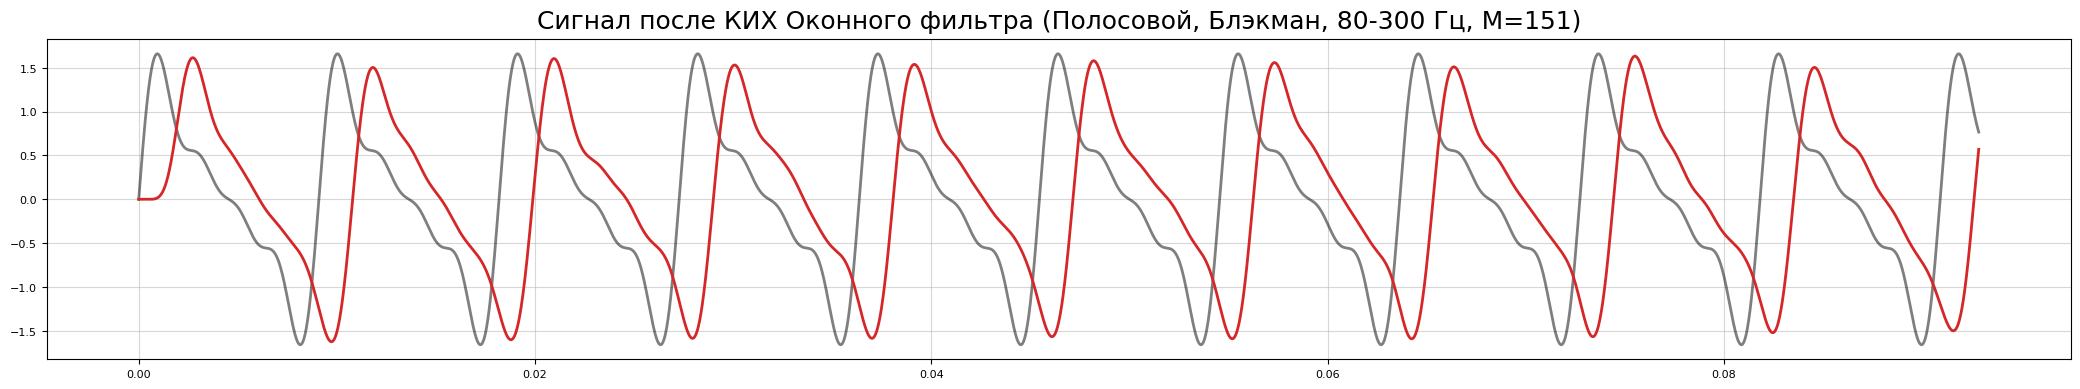

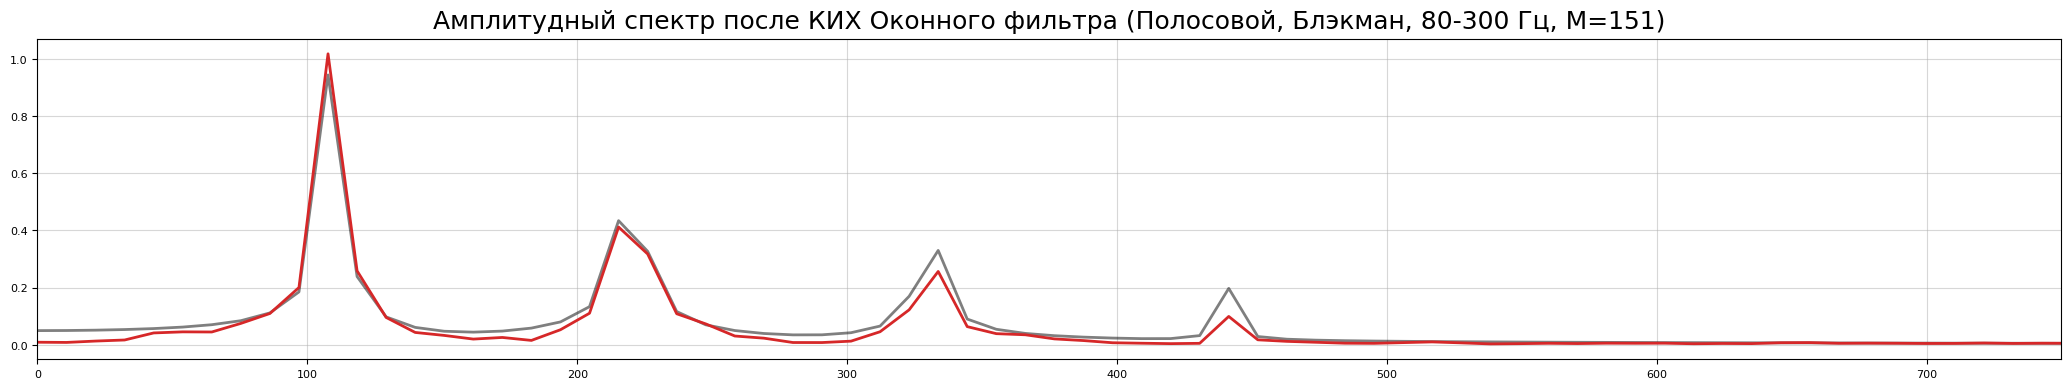

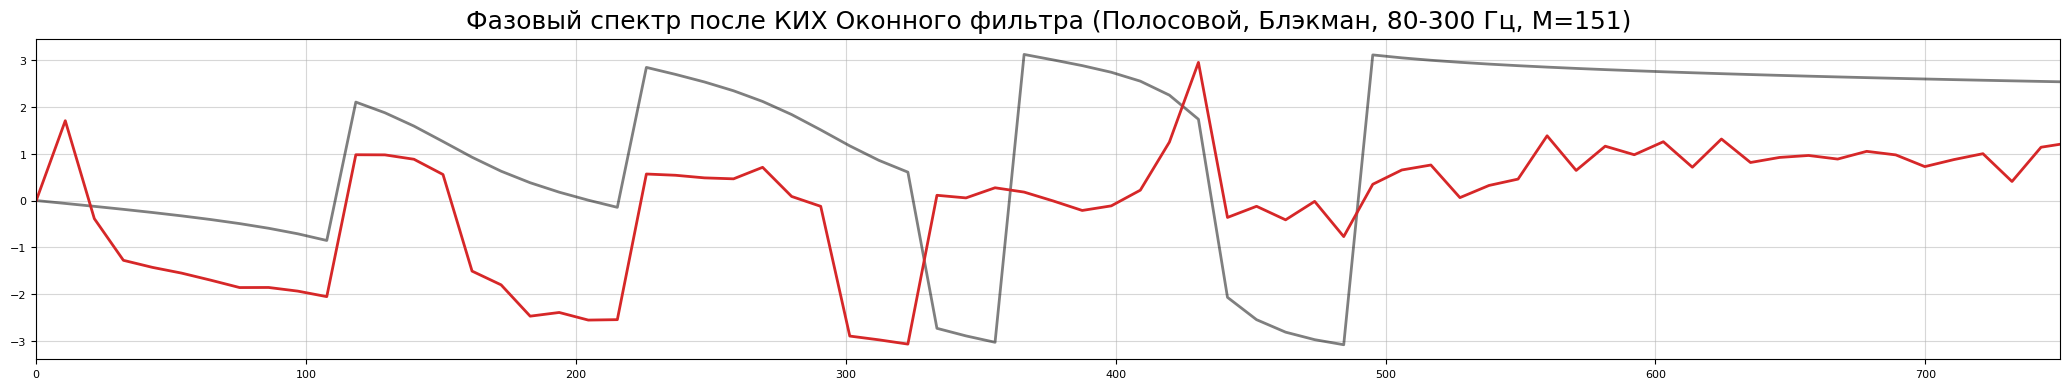

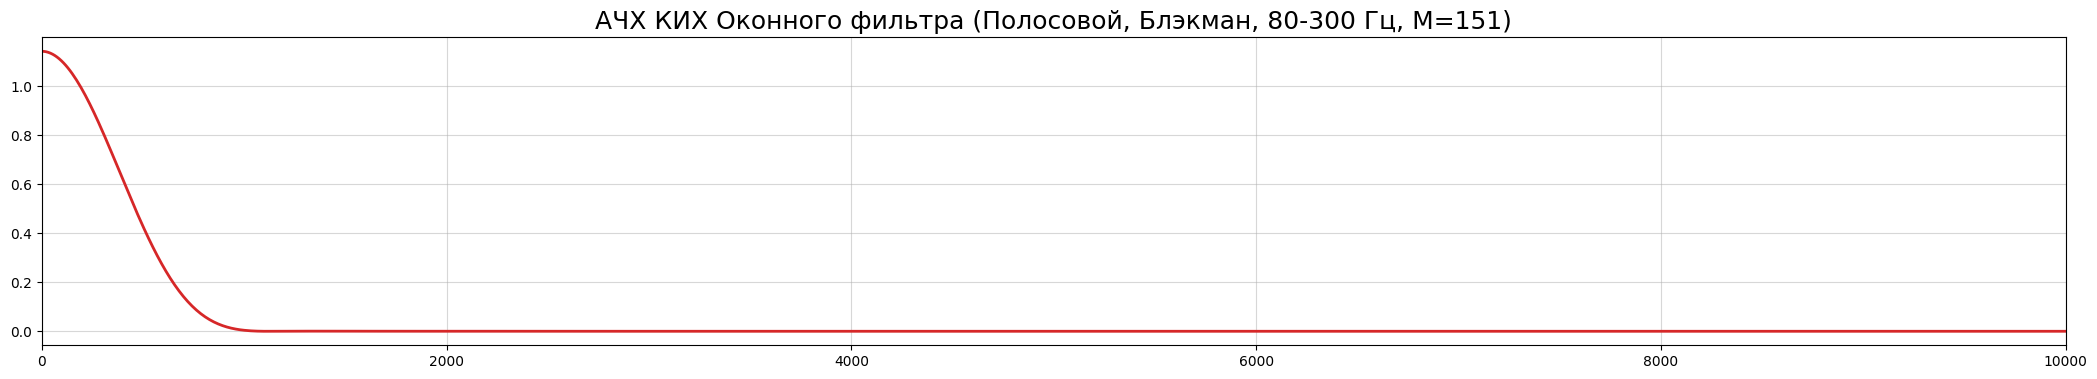

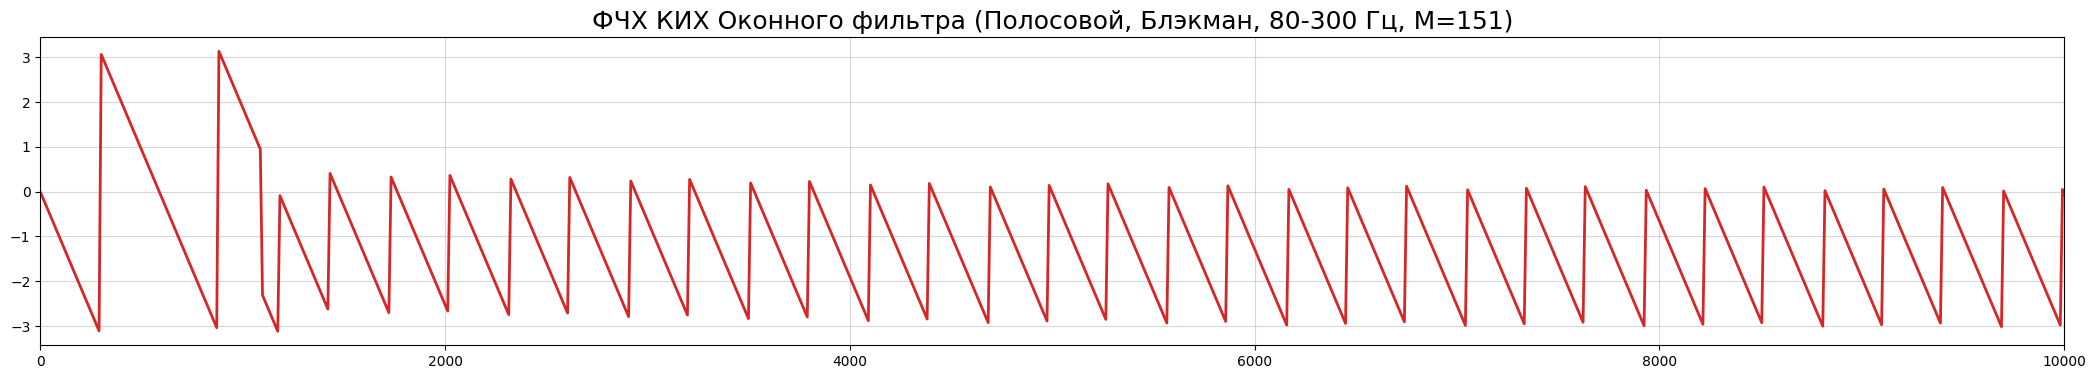

In [76]:
M_fir = 151
f_low = 80
f_high = 300

h_fir = signal.firwin(M_fir, [f_low, f_high], pass_zero=False, 
                      window='blackman', fs=fs)

def apply_fir_manual(x_in, h_coeffs):
    N = len(h_coeffs)
    L = len(x_in)
    y = np.zeros(L)
    
    for n in range(L):
        for k in range(N):
            if n - k >= 0:
                y[n] += h_coeffs[k] * x_in[n - k]
    return y

y_fir_manual = apply_fir_manual(x_noisy, h_fir)

Y_fft_fir = fft(y_fir_manual)
mag_fir = 2 * np.abs(Y_fft_fir[:N_plot//2]) / N_plot
phase_fir = np.angle(Y_fft_fir[:N_plot//2])

w, h_freq = signal.freqz(h_fir, worN=N_plot//2)
response_mag_fir = np.abs(h_freq)
response_phase_fir = np.angle(h_freq)
freq_hz_fir = w * fs / (2 * np.pi)

draw_comparison_plot(t_plot, x, y_fir_manual, f"Сигнал после КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})")
draw_comparison_plot(freq[:N_plot//2], mag, mag_fir, f"Амплитудный спектр после КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})", x_lim=750)
draw_comparison_plot(freq[:N_plot//2], phase, phase_fir, f"Фазовый спектр после КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})", x_lim=750)
draw_characteristics(freq_hz_fir, response_mag_fir, response_phase_fir,
                     f"АЧХ КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})",
                     f"ФЧХ КИХ Оконного фильтра (Полосовой, Блэкман, {f_low}-{f_high} Гц, M={M_fir})", x_lim=10000)

#### БИХ Фильтр:

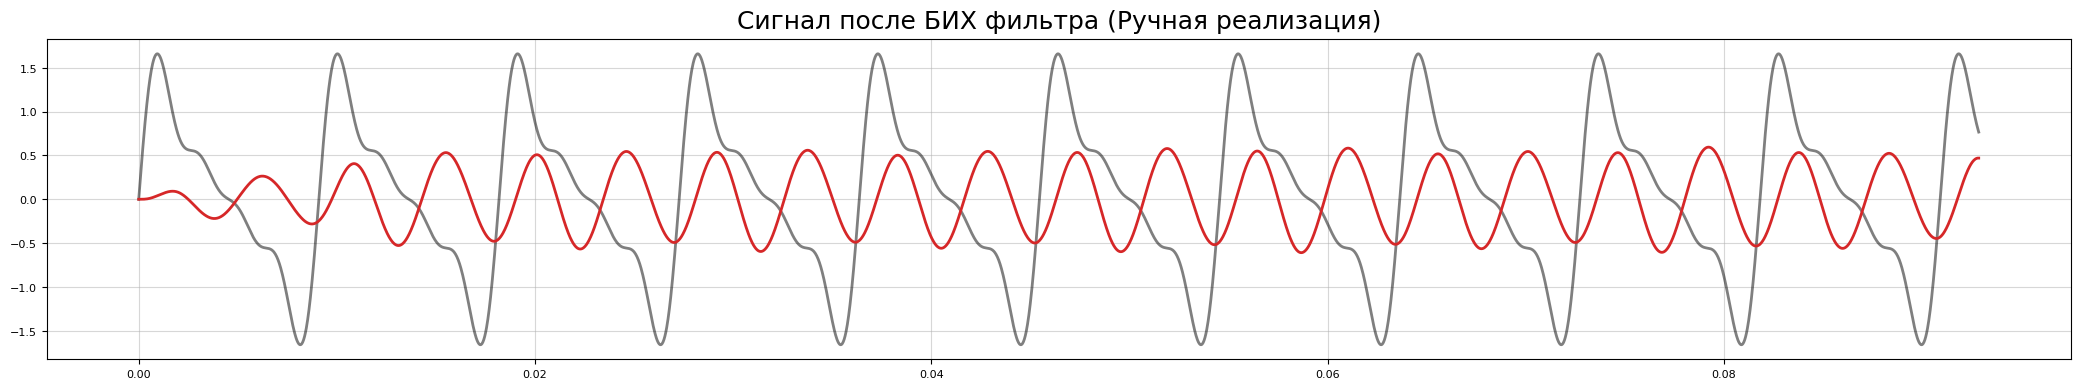

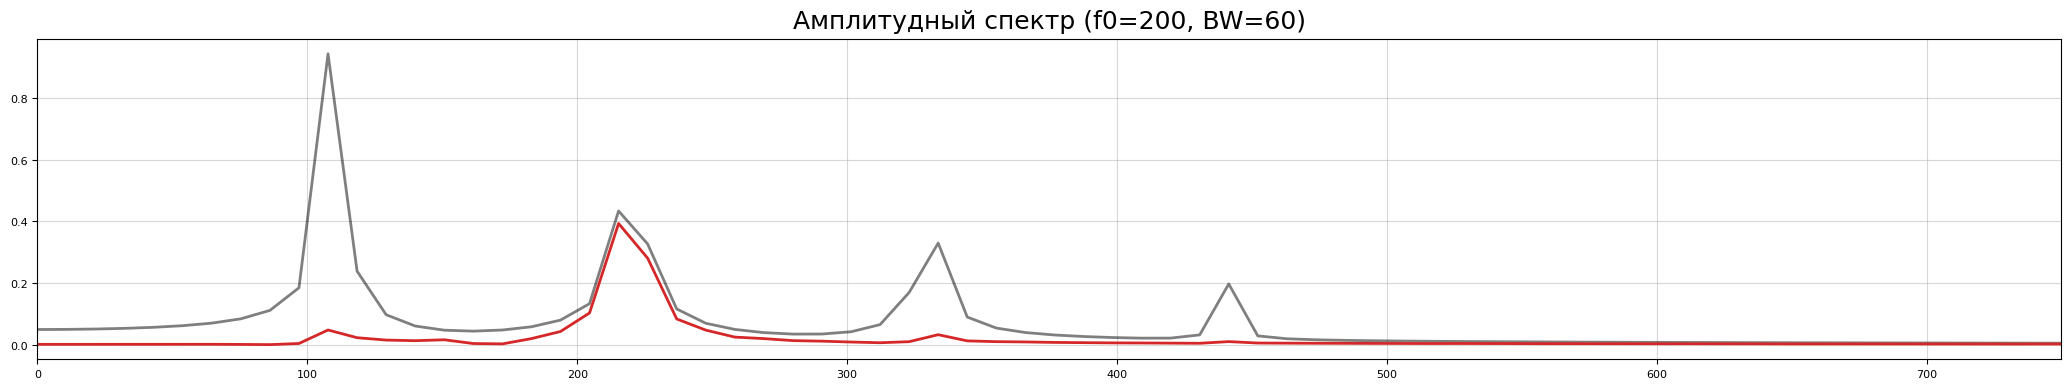

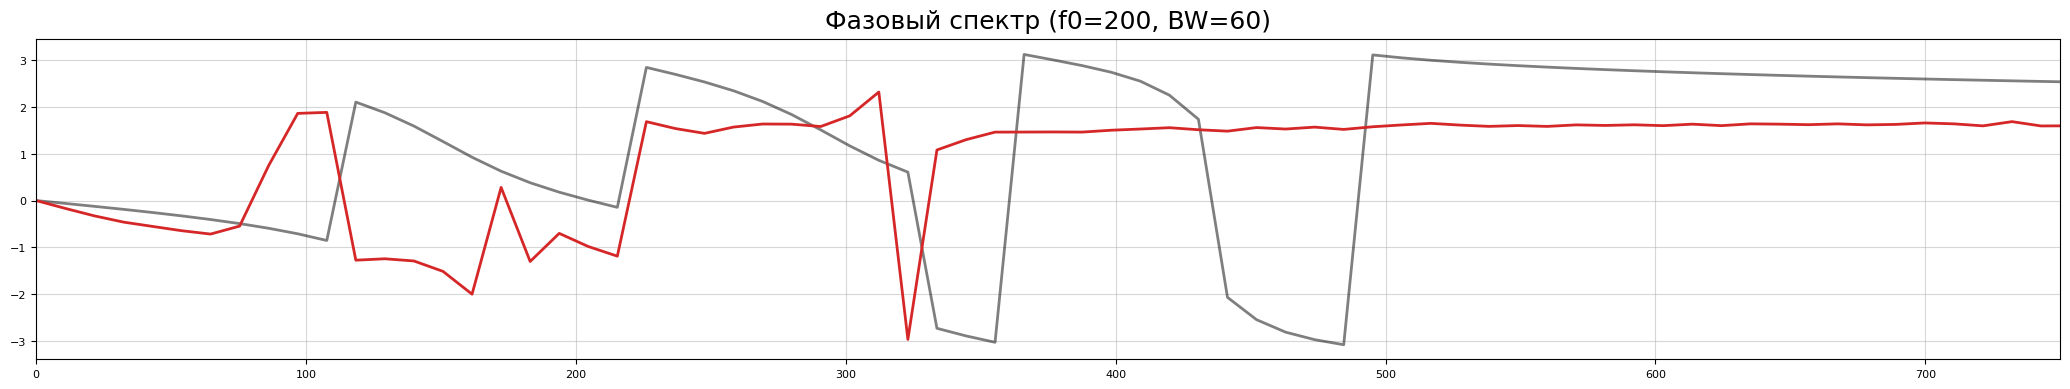

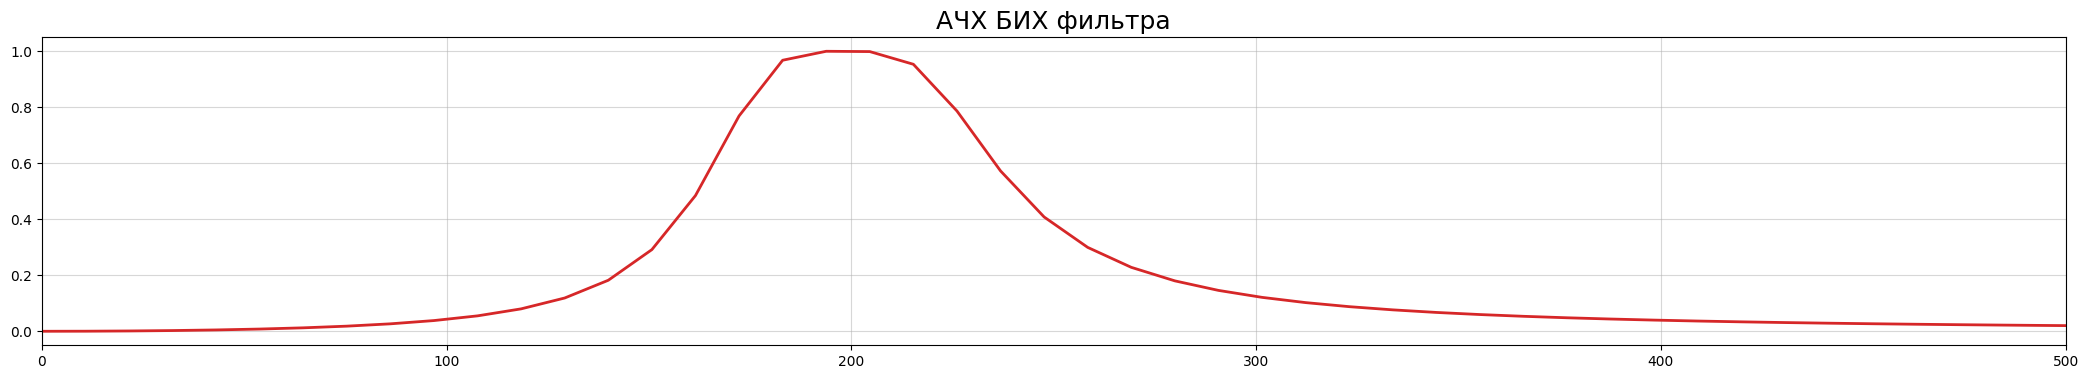

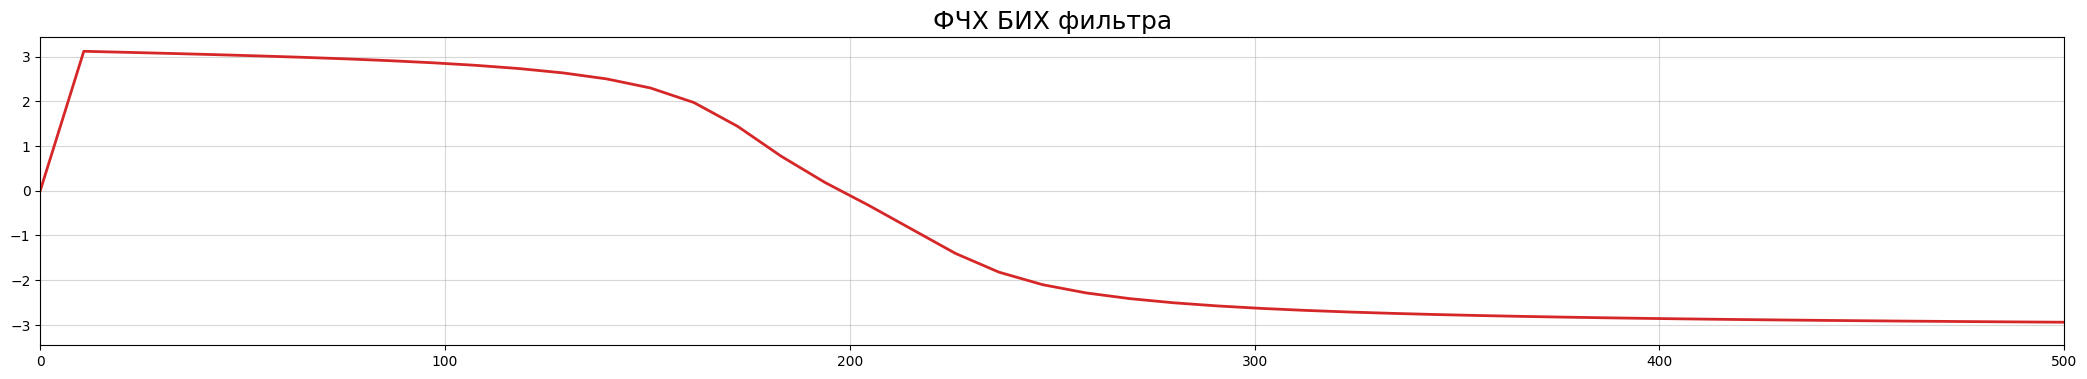

In [ ]:
f0 = 200
bw = 60
f_low = f0 - bw/2
f_high = f0 + bw/2

b_iir, a_iir = signal.butter(2, [f_low, f_high], btype='bandpass', fs=fs)

def apply_iir_manual(x_in, b, a):
    M = len(b)
    N = len(a)
    L = len(x_in)
    y = np.zeros(L)
    
    for n in range(L):
        for i in range(M):
            if n - i >= 0:
                y[n] += b[i] * x_in[n - i]
        
        for j in range(1, N):
            if n - j >= 0:
                y[n] -= a[j] * y[n - j]
        
        y[n] /= a[0]
    return y

y_iir_manual = apply_iir_manual(x_noisy, b_iir, a_iir)

Y_fft_iir = fft(y_iir_manual)
mag_iir = 2 * np.abs(Y_fft_iir[:N_plot//2]) / N_plot
phase_iir = np.angle(Y_fft_iir[:N_plot//2])

w, h_freq = signal.freqz(b_iir, a_iir, worN=N_plot//2)
response_mag_iir = np.abs(h_freq)
response_phase_iir = np.angle(h_freq)
freq_hz_iir = w * fs / (2 * np.pi)

draw_comparison_plot(t_plot, x, y_iir_manual, f"Сигнал после БИХ фильтра (Полосовой, f0={f0} Гц, BW={bw} Гц)")
draw_comparison_plot(freq[:N_plot//2], mag, mag_iir, f"Амплитудный спектр (Полосовой, f0={f0} Гц, BW={bw} Гц)", x_lim=750)
draw_comparison_plot(freq[:N_plot//2], phase, phase_iir, f"Фазовый спектр (Полосовой, f0={f0} Гц, BW={bw} Гц)", x_lim=750)
draw_characteristics(freq_hz_iir, response_mag_iir, response_phase_iir, 
                     f"АЧХ БИХ фильтра (Полосовой, f0={f0} Гц, BW={bw} Гц)", 
                     f"ФЧХ БИХ фильтра (Полосовой, f0={f0} Гц, BW={bw} Гц)", x_lim=500)

#### Аудио:

In [78]:
import os
from scipy.io.wavfile import write

output_dir = "files/lab02"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

duration_s = 5
t_audio = np.arange(int(fs * duration_s)) / fs

x_long = generate_signal(A_x, f0_x, h_x, t_audio)

noise_long = 0.3 * np.random.normal(size=len(t_audio))
x_noisy_long = x_long + noise_long

y_moving_avg = np.zeros_like(x_noisy_long)
M_val = 79
x_padded_long = np.pad(x_noisy_long, (M_val, 0), mode='constant')
for n in range(M_val, len(x_padded_long)):
    y_moving_avg[n-M_val] = (x_padded_long[n] - x_padded_long[n-M_val])
y_moving_avg = np.cumsum(y_moving_avg) / M_val

y_fir_long = apply_fir_manual(x_noisy_long, h_fir)
y_iir_long = apply_iir_manual(x_noisy_long, b_iir, a_iir)

def save_wav(name, data):
    norm = data / np.max(np.abs(data))
    path = os.path.join(output_dir, name)
    write(path, fs, (norm * 32767).astype(np.int16))

save_wav("1-Clean.wav", x_long)
save_wav("2-Noisy.wav", x_noisy_long)
save_wav("3-FilterMovingAvg.wav", y_moving_avg)
save_wav("4-FilterFIR.wav", y_fir_long)
save_wav("5-FilterIIR.wav", y_iir_long)